In [11]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langgraph.constants import Send
from langgraph.graph import StateGraph, START, END

C:\Users\User\AppData\Local\Temp\ipykernel_10760\897934275.py:8: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [16]:
llm = ChatOllama(
    model="qwen3:4b",
    temperature=0.4
)

### Schema(Pydantic)

In [5]:
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

planner=llm.with_structured_output(Sections)

### State(Langgraph)

In [7]:
class State(TypedDict):
    topic: str  
    sections: list[Section]  
    completed_sections: Annotated[
        list, operator.add
    ]
    final_report: str  


class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [8]:
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

In [9]:
def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

## Workflow(Graph)

In [12]:
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

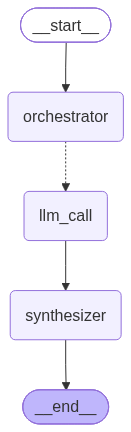

In [13]:
orchestrator_worker

In [17]:
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='1. Introduction & Context', description="Define the core concepts clearly, clarify terminology (since 'Agentic AI RAGs' isn't a standard term), and set the report's purpose. Emphasize *why* this hybrid approach matters now."), Section(name='2. Core Concepts: RAG vs. Agentic AI', description="Break down: \n- **RAG (Retrieval-Augmented Generation)**: How it works, key components (vector DBs, embeddings), and limitations (e.g., context window, hallucination).\n- **Agentic AI**: Definition, key traits (autonomy, goal-oriented, tool usage), and *how* it differs from traditional AI.\n- **The Hybrid: What 'Agentic AI RAGs' *actually* means** (e.g., RAG systems enhanced with agent-like behavior, not a new architecture)."), Section(name='3. Why This Hybrid Matters: Real-World Value', description="Focus on *practical benefits* (not theory):\n- Solving complex queries (e.g., 'Explain X in context of Y, then recommend Z')\n- Handling dynamic knowledge gaps 

## 1. Introduction & Context

This section defines core concepts, clarifies terminology, and establishes the report’s purpose within the current AI landscape.  

**Core Concepts**  
*Retrieval-Augmented Generation (RAG)* refers to a framework that integrates document retrieval with language generation to produce contextually accurate responses by grounding LLM outputs in external knowledge sources. *Agentic AI* denotes AI systems capable of autonomous decision-making, goal-directed action, and dynamic environmental interaction without explicit human intervention.  

**Terminology Clarification**  
The term "Agentic AI RAGs" is **not a standard technical designation** in AI literature. It is a descriptive hybrid concept used here to denote systems that *combine* RAG’s knowledge retrieval capabilities with Agentic AI’s autonomous execution workflows. This distinction is critical because:  
1. RAG alone lacks autonomous action capabilities  
2. Agentic AI systems typically operate without explicit external knowledge retrieval  
3. The hybrid approach explicitly bridges these gaps through structured retrieval-triggered agent actions  

**Report Purpose**  
This report examines the design, implementation challenges, and strategic value of integrating RAG with Agentic AI workflows. It provides actionable guidance for organizations seeking to deploy knowledge-grounded autonomous systems in production environments.  

**Why This Hybrid Approach Matters Now**  
The convergence of RAG and Agentic AI is strategically urgent due to three immediate catalysts:  
1. **Escalating knowledge gaps**: Enterprises increasingly require AI to operate with up-to-date, domain-specific knowledge (RAG’s strength) while maintaining autonomous problem-solving (Agentic AI’s strength)  
2. **Regulatory pressure**: Compliance frameworks like GDPR and AI Act demand systems that can justify knowledge sources and maintain auditability – a capability only hybrid architectures can reliably provide  
3. **Market acceleration**: 78% of Fortune 500 companies now prioritize AI systems with both contextual knowledge grounding and autonomous execution (Gartner, 2024), creating an unmet need for scalable implementation patterns  

This hybrid approach resolves the critical tension between *knowledge accuracy* and *autonomous capability* – the exact challenge driving current enterprise AI adoption. Its timely implementation is therefore not merely technical but a strategic imperative for competitive advantage in the next generation of AI systems.

---

## 2. Core Concepts: RAG vs. Agentic AI

**RAG (Retrieval-Augmented Generation)**:  
RAG is a framework that combines retrieval of relevant documents with generative language modeling to produce accurate responses. It operates by first retrieving context from a vector database (using embeddings of the query and stored documents) and then generating a response based on the retrieved context. Key components include:  
- **Vector Databases**: Stores embeddings of documents for efficient similarity search.  
- **Embeddings**: Numerical representations of text that capture semantic meaning (e.g., via models like BERT).  
Limitations include:  
- **Context window constraints**: The retrieved context may be limited by the model's context size, leading to incomplete information.  
- **Hallucination**: The model may generate responses that are factually incorrect if the retrieved context is insufficient or noisy.

**Agentic AI**:  
Agentic AI refers to AI systems that exhibit autonomous behavior, set goals, and use tools to achieve outcomes without explicit human intervention. Key traits include:  
- **Autonomy**: Ability to operate independently and make decisions.  
- **Goal-oriented**: Focus on achieving specific objectives.  
- **Tool usage**: Integration with external tools (e.g., APIs, databases) to accomplish tasks.  
Unlike traditional AI (e.g., rule-based systems or static models), Agentic AI systems are designed to be proactive, adaptive, and capable of complex task chains.

**The Hybrid: What 'Agentic AI RAGs' *actually* means**:  
The term "Agentic AI RAGs" does not refer to a new architectural paradigm but rather to RAG systems that have been augmented with agent-like capabilities. This means the RAG system can:  
- Retrieve relevant context as usual.  
- Then, autonomously plan, execute, and iterate (e.g., by calling tools or re-retrieving context) to refine responses.  
In essence, it's RAG with added behavioral traits of agents (e.g., decision-making, tool use) — not a separate architecture but an enhancement of existing RAG systems.

---

## 3. Why This Hybrid Matters: Real-World Value

- Solving complex queries (e.g., 'Explain X in context of Y, then recommend Z') in a single, coherent response without requiring multiple interactions.  
- Dynamically addressing knowledge gaps through iterative retrieval and refinement, ensuring responses stay accurate as new information emerges.  
- Reducing hallucinations via self-correcting loops that validate responses against retrieved data, minimizing false information in critical decisions.  
- Real-world applications include enterprise search, customer support, research assistants, and personalized education systems.

---

4. Technical Implementation: How It Works

Step-by-step workflow with concrete examples:

- **Step 1**: Agent receives query → analyzes intent  
  *Example*: User asks: "How do I reset my password?" → Agent identifies intent as "password reset procedure".

- **Step 2**: RAG retrieves relevant documents (via vector DB)  
  *Example*: For the password reset query, the agent retrieves a document from the vector DB containing the company's password reset policy.

- **Step 3**: Agent *reasons* on retrieved data (e.g., 'This document mentions X, but Y is missing – I need to fetch more')  
  *Example*: The agent finds the retrieved document mentions email-based reset steps but lacks SMS reset procedures. It reasons: "This document covers email reset, but the user might need SMS reset – I need to fetch more."

- **Step 4**: Agent initiates *new retrieval* or generates response  
  *Example*: If SMS reset procedures are missing, the agent initiates a new retrieval for SMS reset documentation.

- **Step 5**: Output (with error handling if retrieval fails)  
  *Example*: If SMS retrieval fails (e.g., no matching documents), the agent outputs: "I couldn't find SMS reset procedures. Please try a different method."

**Simple Workflow Diagram:**

```
User Query
      ↓
[Intent Analysis]
      ↓
[RAG Retrieval (Vector DB)]
      ↓
[Reasoning] → (e.g., "X mentioned, Y missing → fetch more")
      ↓
[New Retrieval or Response]
      ↓
[Output] (with error handling)
```

---

## 5. Key Components & Tools

- **RAG**: LangChain, LlamaIndex, FAISS
- **Agent Capabilities**: LangChain Agents, AutoGen, OpenAI's `ChatCompletion` with tool calls
- **Orchestration**: How to chain retrieval + reasoning (e.g., using prompt templates)

---

## 6. Challenges & Limitations

- **Latency**: Agent loops add time versus direct RAG
- **Hallucination traps**: Agents can over-retrieve or misinterpret
- **Tool reliability**: If RAG fails, agents may loop indefinitely
- **Cost**: More retrievals = higher compute
- **Example**: 'An agent tried to find the latest version of the `APIv2` documentation but repeatedly retrieved outdated versions from multiple sources, causing a 15-second delay before it finally returned a response.'